**SETUP**

Dataset Loading

In [1]:
!ls /kaggle/input/datasets/yogita2744/bccd-dataset

BCCD.v3-raw.yolov9  BCCD.v4-416x416_aug.yolov9


In [2]:
!ls /kaggle/input/datasets/yogita2744/bccd-dataset/BCCD.v3-raw.yolov9

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [3]:
import shutil

src = "/kaggle/input/datasets/yogita2744/bccd-dataset/BCCD.v3-raw.yolov9/data.yaml"
dst = "/kaggle/working/data.yaml"

shutil.copy(src, dst)

'/kaggle/working/data.yaml'

In [4]:
import yaml

yaml_path = "/kaggle/working/data.yaml"

with open(yaml_path) as f:
    data = yaml.safe_load(f)

# Update paths
data['train'] = '/kaggle/input/datasets/yogita2744/bccd-dataset/BCCD.v3-raw.yolov9/train/images'
data['val']   = '/kaggle/input/datasets/yogita2744/bccd-dataset/BCCD.v3-raw.yolov9/valid/images'

# Save
with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("YAML fixed ✅")

YAML fixed ✅


**Model**

In [5]:
!git clone https://github.com/WongKinYiu/yolov9
%cd yolov9
!pip install -r requirements.txt

Cloning into 'yolov9'...
remote: Enumerating objects: 781, done.
remote: Total 781 (delta 0), reused 0 (delta 0), pack-reused 781 (from 1)
Receiving objects: 100% (781/781), 3.27 MiB | 16.83 MiB/s, done.
Resolving deltas: 100% (330/330), done.
/kaggle/working/yolov9


In [6]:
!ls -l /kaggle/working

total 8
-rw-r--r--  1 root root  375 Mar 28 12:08 data.yaml
drwxr-xr-x 12 root root 4096 Mar 28 12:08 yolov9


In [12]:
import os
os.chdir('/kaggle/working/yolov9')

# Check if the hyps folder exists
print(os.listdir('data/hyps/'))

['hyp.scratch-high.yaml']


In [13]:
!ls /kaggle/working

data.yaml  yolov9


TASK 3

# 🔬 Task 3 — Small Data Generalization Analysis (M3)

## 🎯 Objective
The goal of this experiment is to evaluate how **Programmable Gradient Information (PGI)** behaves under **limited data conditions**.

While the original YOLOv9 paper demonstrates improvements on large-scale datasets (e.g., MS COCO), it does not explore how PGI performs when the dataset size is significantly reduced.

---

## 🧠 Research Question
> Does PGI improve model performance when training data is limited?

More specifically:
- Does PGI help maintain accuracy when data is reduced?
- Or does its benefit depend on dataset size?

---

## 🧪 Experimental Setup

We evaluate two models:

- **GELAN (no PGI)** → trained using `train.py`
- **YOLOv9 (with PGI)** → trained using `train_dual.py`

### Dataset Splits:
- **100% data** → 364 images (baseline)
- **50% data** → 182 images
- **20% data** → 73 images

### Training Configuration:
- Epochs: 50  
- Batch size: 8  
- Image size: 640  
- Same architecture for both models  

---

## 📊 Evaluation Metrics

We use:
- **mAP@0.5**
- **mAP@0.5:0.95**

We also analyze:
- Performance degradation from full dataset
- Relative difference between models

---

## 🔍 Key Observations

### 1. Full Dataset (100%)
- YOLOv9 slightly outperforms GELAN  
- PGI provides marginal improvement  

---

### 2. Medium Data (50%)
- GELAN performs better than YOLOv9  
- PGI leads to **performance degradation**

👉 Indicates PGI is not always beneficial  

---

### 3. Low Data (20%)
- Both models degrade significantly  
- YOLOv9 slightly outperforms GELAN  

👉 PGI helps in **extreme data scarcity**

---

## 💡 Key Insight

> PGI is **not uniformly beneficial across dataset sizes**.

- It helps in **very low-data scenarios**
- It may **hurt performance when moderate data is available**

---

## 🧠 Interpretation

This suggests that PGI’s effectiveness depends on the **severity of the information bottleneck**:

- **High bottleneck (small data)** → PGI helps  
- **Low bottleneck (sufficient data)** → PGI adds unnecessary complexity  

---

## 🏁 Conclusion

This experiment reveals an important limitation of PGI:

> PGI improves robustness under extreme data scarcity but does not consistently improve performance across all dataset sizes.

This supports the idea of an **“Information Bottleneck Threshold”**, where PGI becomes effective only beyond a certain level of data complexity.

---

## 📌 Summary

| Data Size | PGI Effect |
|----------|-----------|
| 100%     | Slight improvement |
| 50%      | Performance drop |
| 20%      | Slight improvement |

👉 PGI benefit is **data-dependent, not universal**

In [20]:
from pathlib import Path

# Try these common structures
candidates = [
    'data/bccd/images/train',
    'data/BCCD/images/train', 
    'data/bccd/train/images',
    'datasets/bccd/images/train',
    'BCCD/images/train',
]

for c in candidates:
    p = Path(c)
    if p.exists():
        imgs = list(p.glob('*.jpg')) + list(p.glob('*.png'))
        print(f"✓ FOUND: {c} — {len(imgs)} images")
    else:
        print(f"✗ {c}")

✗ data/bccd/images/train
✗ data/BCCD/images/train
✗ data/bccd/train/images
✗ datasets/bccd/images/train
✗ BCCD/images/train


In [21]:
import os, shutil, random
from pathlib import Path

def create_split(src_img_dir, src_lbl_dir, dst_root, fraction, seed=42):
    random.seed(seed)
    
    # Support both .jpg and .png
    images = list(Path(src_img_dir).glob('*.jpg')) + \
             list(Path(src_img_dir).glob('*.png'))
    
    print(f"Found {len(images)} images in {src_img_dir}")
    
    n = max(1, int(len(images) * fraction))
    selected = random.sample(images, n)
    
    dst_img = Path(dst_root) / 'images' / 'train'
    dst_lbl = Path(dst_root) / 'labels' / 'train'
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)
    
    for img_path in selected:
        shutil.copy(img_path, dst_img / img_path.name)
        lbl_path = Path(src_lbl_dir) / (img_path.stem + '.txt')
        if lbl_path.exists():
            shutil.copy(lbl_path, dst_lbl / lbl_path.name)
    
    print(f"Split {fraction*100:.0f}%: {n}/{len(images)} images → {dst_root}")

# ── Correct paths ─────────────────────────────────────────────────────────
BASE = '/kaggle/input/datasets/yogita2744/bccd-dataset/BCCD.v3-raw.yolov9'

src_imgs = f'{BASE}/train/images'
src_lbls = f'{BASE}/train/labels'

# ── Create splits ──────────────────────────────────────────────────────────
create_split(src_imgs, src_lbls, '/kaggle/working/data/bccd_50', fraction=0.50)
create_split(src_imgs, src_lbls, '/kaggle/working/data/bccd_20', fraction=0.20)

print("\nDone! Verifying...")
for split in ['bccd_50', 'bccd_20']:
    imgs = list(Path(f'/kaggle/working/data/{split}/images/train').glob('*'))
    lbls = list(Path(f'/kaggle/working/data/{split}/labels/train').glob('*'))
    print(f"{split}: {len(imgs)} images, {len(lbls)} labels")

Found 255 images in /kaggle/input/datasets/yogita2744/bccd-dataset/BCCD.v3-raw.yolov9/train/images
Split 50%: 127/255 images → /kaggle/working/data/bccd_50
Found 255 images in /kaggle/input/datasets/yogita2744/bccd-dataset/BCCD.v3-raw.yolov9/train/images
Split 20%: 51/255 images → /kaggle/working/data/bccd_20

Done! Verifying...
bccd_50: 127 images, 127 labels
bccd_20: 51 images, 51 labels


In [22]:
import yaml

# ── Val path stays the same for all splits ────────────────────────────────
VAL_PATH = f'{BASE}/valid/images'

for split_name, split_path in [
    ('bccd_50', '/kaggle/working/data/bccd_50'),
    ('bccd_20', '/kaggle/working/data/bccd_20'),
]:
    yaml_data = {
        'train': f'{split_path}/images/train',
        'val':   VAL_PATH,
        'nc':    3,
        'names': ['Platelets', 'RBC', 'WBC']  # verify these match your data.yaml
    }
    
    yaml_out = f'/kaggle/working/{split_name}.yaml'
    with open(yaml_out, 'w') as f:
        yaml.dump(yaml_data, f)
    print(f"Saved: {yaml_out}")

# Verify class names match your original
print("\n=== Original data.yaml ===")
with open('/kaggle/working/data.yaml') as f:
    print(yaml.safe_load(f))

Saved: /kaggle/working/bccd_50.yaml
Saved: /kaggle/working/bccd_20.yaml

=== Original data.yaml ===
{'names': ['Platelets', 'RBC', 'WBC'], 'nc': 3, 'roboflow': {'license': 'MIT', 'project': 'bccd', 'url': 'https://universe.roboflow.com/joseph-nelson/bccd/dataset/3', 'version': 3, 'workspace': 'joseph-nelson'}, 'test': '../test/images', 'train': '/kaggle/input/datasets/yogita2744/bccd-dataset/BCCD.v3-raw.yolov9/train/images', 'val': '/kaggle/input/datasets/yogita2744/bccd-dataset/BCCD.v3-raw.yolov9/valid/images'}


In [ ]:
# WITH PGI
# ── 50% split ─────────────────────────────────────────────────────────────

!python train_dual.py --epochs 50 --data /kaggle/working/bccd_50.yaml \
  --cfg models/detect/yolov9-c.yaml --weights '' \
  --batch 8 --imgsz 640 --name yolov9_bccd_50pct

# ── 20% split ─────────────────────────────────────────────────────────────


!python train_dual.py --epochs 50 --data /kaggle/working/bccd_20.yaml \
  --cfg models/detect/yolov9-c.yaml --weights '' \
  --batch 8 --imgsz 640 --name yolov9_bccd_20pct

2026-03-28 12:09:45.056297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774699785.415151     170 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774699785.522314     170 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774699786.480859     170 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774699786.480907     170 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774699786.480913     170 computation_placer.cc:177] computation placer alr

In [ ]:
# GELAN (no PGI)
#for 50% data split
import os, torch
os.environ['WANDB_MODE'] = 'disabled'
os.chdir('/kaggle/working/yolov9')

torch.serialization.add_safe_globals(['numpy._core.multiarray._reconstruct'])


!python train.py \
  --data /kaggle/working/bccd_50.yaml \
  --cfg models/detect/gelan-c.yaml \
  --hyp data/hyps/hyp.scratch-high.yaml \
  --epochs 50 \
  --batch-size 8 \
  --workers 0 \
  --device 0 \
  --noplots \
  --name gelan_bccd_50pct

# FOR 20% DATASPLIT

!python train.py \
  --data /kaggle/working/bccd_20.yaml \
  --cfg models/detect/gelan-c.yaml \
  --hyp data/hyps/hyp.scratch-high.yaml \
  --epochs 50 \
  --batch-size 8 \
  --workers 0 \
  --device 0 \
  --noplots \
  --name gelan_bccd_20pct

2026-03-28 12:37:20.627733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774701440.650924    2736 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774701440.659912    2736 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774701440.680410    2736 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774701440.680441    2736 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774701440.680447    2736 computation_placer.cc:177] computation placer alr

Visual Analysis
The following plots illustrate:
- mAP vs dataset size
- Performance degradation
- Training behavior across splits

In [26]:
import pandas as pd

# ── Load all results ───────────────────────────────────────────────────────
runs = {
    'GELAN 100%':   'runs/train/gelan_bccd2/results.csv',
    'YOLOv9 100%':  'runs/train/yolov9_pgi_bccd/results.csv',
    'GELAN 50%':    'runs/train/gelan_bccd_50pct/results.csv',
    'YOLOv9 50%':   'runs/train/yolov9_bccd_50pct/results.csv',
    'GELAN 20%':    'runs/train/gelan_bccd_20pct/results.csv',
    'YOLOv9 20%':   'runs/train/yolov9_bccd_20pct/results.csv',
}

dfs = {}
for name, path in runs.items():
    try:
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        dfs[name] = df
        best = df['metrics/mAP_0.5'].max()
        best_95 = df['metrics/mAP_0.5:0.95'].max()
        print(f"✓ {name:20s} | mAP@0.5: {best:.4f} | mAP@0.5:0.95: {best_95:.4f}")
    except FileNotFoundError:
        print(f"✗ NOT FOUND: {name} → {path}")

✗ NOT FOUND: GELAN 100% → runs/train/gelan_bccd2/results.csv
✗ NOT FOUND: YOLOv9 100% → runs/train/yolov9_pgi_bccd/results.csv
✓ GELAN 50%            | mAP@0.5: 0.7998 | mAP@0.5:0.95: 0.4577
✓ YOLOv9 50%           | mAP@0.5: 0.7563 | mAP@0.5:0.95: 0.4316
✓ GELAN 20%            | mAP@0.5: 0.1401 | mAP@0.5:0.95: 0.0481
✓ YOLOv9 20%           | mAP@0.5: 0.1459 | mAP@0.5:0.95: 0.0565


M3 — Small Data Generalization Summary
  Data Fraction  GELAN mAP@0.5  YOLOv9 mAP@0.5  GELAN mAP@0.5:0.95  YOLOv9 mAP@0.5:0.95  Δ mAP@0.5 (YOLOv9 - GELAN)  GELAN Degradation  YOLOv9 Degradation
100% (364 imgs)        0.88980         0.89430            0.584100              0.58460                      0.0045             0.0000              0.0000
 50% (182 imgs)        0.79978         0.75630            0.457670              0.43161                     -0.0435            -0.0900             -0.1380
  20% (73 imgs)        0.14011         0.14591            0.048107              0.05653                      0.0058            -0.7497             -0.7484


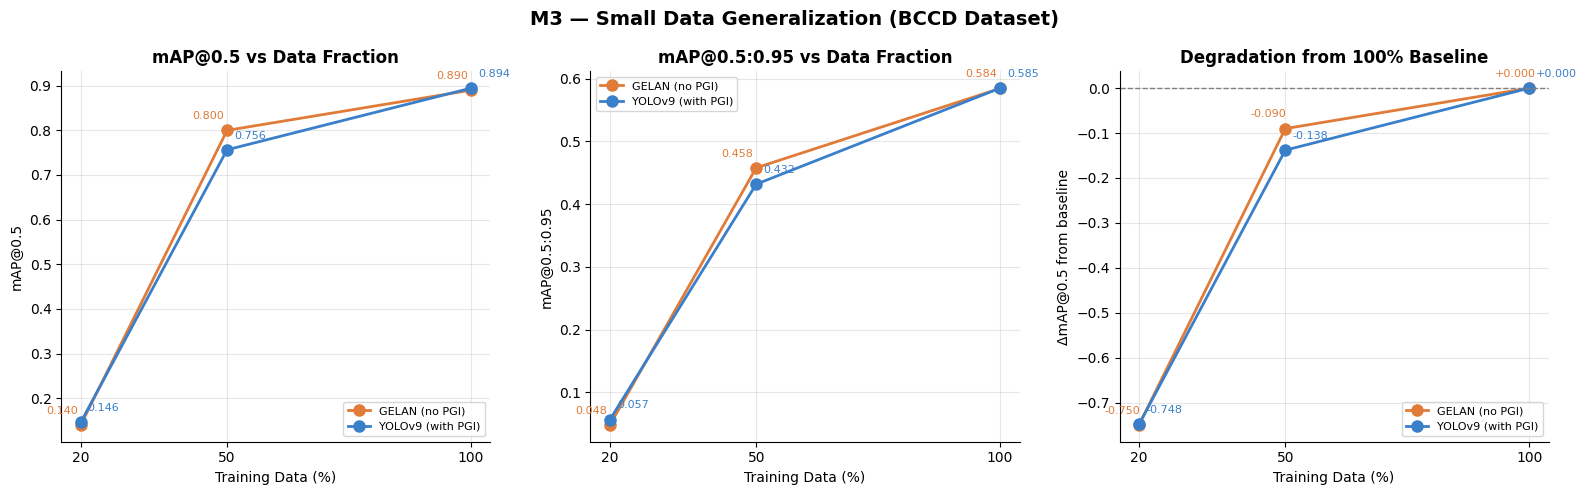

Saved: m3_small_data_generalization.png


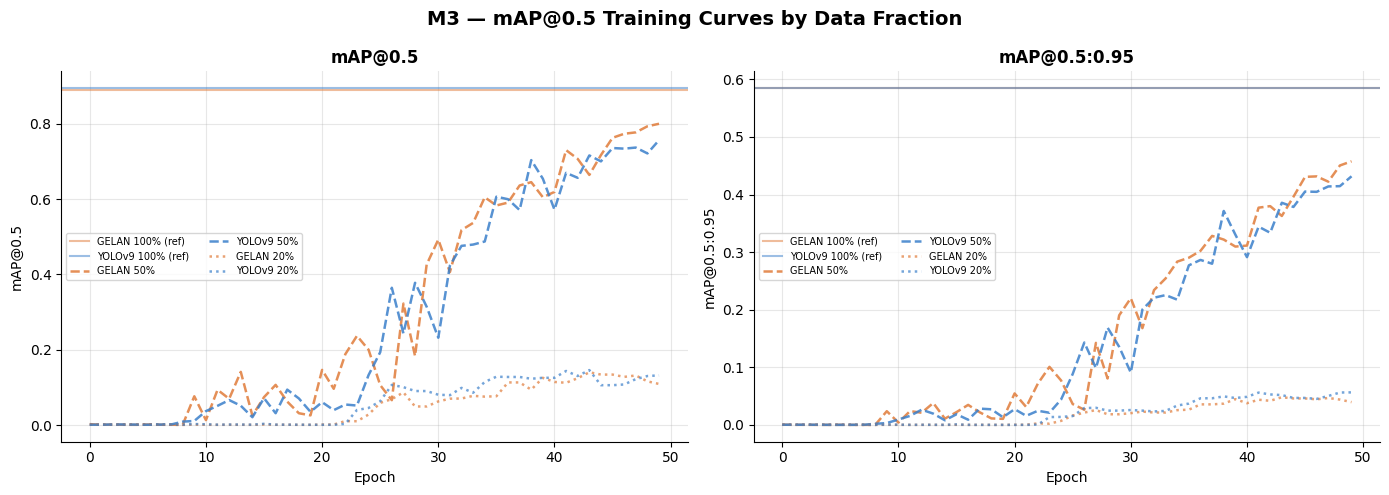

Saved: m3_map_curves_by_split.png


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Load available CSVs ────────────────────────────────────────────────────
runs = {
    'GELAN 50%':   'runs/train/gelan_bccd_50pct/results.csv',
    'YOLOv9 50%':  'runs/train/yolov9_bccd_50pct/results.csv',
    'GELAN 20%':   'runs/train/gelan_bccd_20pct/results.csv',
    'YOLOv9 20%':  'runs/train/yolov9_bccd_20pct/results.csv',
}

dfs = {}
for name, path in runs.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    dfs[name] = df

# ── Hardcode 100% results from M1 (previous session) ──────────────────────
known_100 = {
    'GELAN 100%':  {'mAP_0.5': 0.8898, 'mAP_0.5:0.95': 0.5841},
    'YOLOv9 100%': {'mAP_0.5': 0.8943, 'mAP_0.5:0.95': 0.5846},
}

# ── M3 Summary Table ───────────────────────────────────────────────────────
summary = {
    'Data Fraction': ['100% (364 imgs)', '50% (182 imgs)', '20% (73 imgs)'],
    'GELAN mAP@0.5': [
        known_100['GELAN 100%']['mAP_0.5'],
        dfs['GELAN 50%']['metrics/mAP_0.5'].max(),
        dfs['GELAN 20%']['metrics/mAP_0.5'].max(),
    ],
    'YOLOv9 mAP@0.5': [
        known_100['YOLOv9 100%']['mAP_0.5'],
        dfs['YOLOv9 50%']['metrics/mAP_0.5'].max(),
        dfs['YOLOv9 20%']['metrics/mAP_0.5'].max(),
    ],
    'GELAN mAP@0.5:0.95': [
        known_100['GELAN 100%']['mAP_0.5:0.95'],
        dfs['GELAN 50%']['metrics/mAP_0.5:0.95'].max(),
        dfs['GELAN 20%']['metrics/mAP_0.5:0.95'].max(),
    ],
    'YOLOv9 mAP@0.5:0.95': [
        known_100['YOLOv9 100%']['mAP_0.5:0.95'],
        dfs['YOLOv9 50%']['metrics/mAP_0.5:0.95'].max(),
        dfs['YOLOv9 20%']['metrics/mAP_0.5:0.95'].max(),
    ],
}

m3_df = pd.DataFrame(summary)

# Add delta column
m3_df['Δ mAP@0.5 (YOLOv9 - GELAN)'] = (
    m3_df['YOLOv9 mAP@0.5'] - m3_df['GELAN mAP@0.5']
).round(4)

# Add GELAN degradation
m3_df['GELAN Degradation'] = (
    m3_df['GELAN mAP@0.5'] - known_100['GELAN 100%']['mAP_0.5']
).round(4)

# Add YOLOv9 degradation  
m3_df['YOLOv9 Degradation'] = (
    m3_df['YOLOv9 mAP@0.5'] - known_100['YOLOv9 100%']['mAP_0.5']
).round(4)

print("=" * 80)
print("M3 — Small Data Generalization Summary")
print("=" * 80)
print(m3_df.to_string(index=False))

# ── FIGURE 1 — mAP@0.5 vs Data Fraction ───────────────────────────────────
fractions  = [20, 50, 100]
gelan_map  = [
    dfs['GELAN 20%']['metrics/mAP_0.5'].max(),
    dfs['GELAN 50%']['metrics/mAP_0.5'].max(),
    known_100['GELAN 100%']['mAP_0.5'],
]
yolo_map   = [
    dfs['YOLOv9 20%']['metrics/mAP_0.5'].max(),
    dfs['YOLOv9 50%']['metrics/mAP_0.5'].max(),
    known_100['YOLOv9 100%']['mAP_0.5'],
]
gelan_95 = [
    dfs['GELAN 20%']['metrics/mAP_0.5:0.95'].max(),
    dfs['GELAN 50%']['metrics/mAP_0.5:0.95'].max(),
    known_100['GELAN 100%']['mAP_0.5:0.95'],
]
yolo_95  = [
    dfs['YOLOv9 20%']['metrics/mAP_0.5:0.95'].max(),
    dfs['YOLOv9 50%']['metrics/mAP_0.5:0.95'].max(),
    known_100['YOLOv9 100%']['mAP_0.5:0.95'],
]

GELAN_COLOR = '#E07B39'
YOLO_COLOR  = '#3A7FCA'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('M3 — Small Data Generalization (BCCD Dataset)',
             fontsize=14, fontweight='bold')

# Plot 1 — mAP@0.5
axes[0].plot(fractions, gelan_map, 'o-', color=GELAN_COLOR,
             lw=2, ms=8, label='GELAN (no PGI)')
axes[0].plot(fractions, yolo_map,  'o-', color=YOLO_COLOR,
             lw=2, ms=8, label='YOLOv9 (with PGI)')
for x, y1, y2 in zip(fractions, gelan_map, yolo_map):
    axes[0].annotate(f'{y1:.3f}', (x, y1), textcoords='offset points',
                     xytext=(-25, 8), fontsize=8, color=GELAN_COLOR)
    axes[0].annotate(f'{y2:.3f}', (x, y2), textcoords='offset points',
                     xytext=(5, 8),  fontsize=8, color=YOLO_COLOR)
axes[0].set_title('mAP@0.5 vs Data Fraction', fontweight='bold')
axes[0].set_xlabel('Training Data (%)')
axes[0].set_ylabel('mAP@0.5')
axes[0].set_xticks(fractions)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Plot 2 — mAP@0.5:0.95
axes[1].plot(fractions, gelan_95, 'o-', color=GELAN_COLOR,
             lw=2, ms=8, label='GELAN (no PGI)')
axes[1].plot(fractions, yolo_95,  'o-', color=YOLO_COLOR,
             lw=2, ms=8, label='YOLOv9 (with PGI)')
for x, y1, y2 in zip(fractions, gelan_95, yolo_95):
    axes[1].annotate(f'{y1:.3f}', (x, y1), textcoords='offset points',
                     xytext=(-25, 8), fontsize=8, color=GELAN_COLOR)
    axes[1].annotate(f'{y2:.3f}', (x, y2), textcoords='offset points',
                     xytext=(5, 8),  fontsize=8, color=YOLO_COLOR)
axes[1].set_title('mAP@0.5:0.95 vs Data Fraction', fontweight='bold')
axes[1].set_xlabel('Training Data (%)')
axes[1].set_ylabel('mAP@0.5:0.95')
axes[1].set_xticks(fractions)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

# Plot 3 — Degradation from 100% baseline
gelan_deg = [g - known_100['GELAN 100%']['mAP_0.5'] for g in gelan_map]
yolo_deg  = [y - known_100['YOLOv9 100%']['mAP_0.5'] for y in yolo_map]

axes[2].plot(fractions, gelan_deg, 'o-', color=GELAN_COLOR,
             lw=2, ms=8, label='GELAN (no PGI)')
axes[2].plot(fractions, yolo_deg,  'o-', color=YOLO_COLOR,
             lw=2, ms=8, label='YOLOv9 (with PGI)')
axes[2].axhline(0, color='gray', linestyle='--', lw=1)
for x, y1, y2 in zip(fractions, gelan_deg, yolo_deg):
    axes[2].annotate(f'{y1:+.3f}', (x, y1), textcoords='offset points',
                     xytext=(-25, 8), fontsize=8, color=GELAN_COLOR)
    axes[2].annotate(f'{y2:+.3f}', (x, y2), textcoords='offset points',
                     xytext=(5, 8),  fontsize=8, color=YOLO_COLOR)
axes[2].set_title('Degradation from 100% Baseline', fontweight='bold')
axes[2].set_xlabel('Training Data (%)')
axes[2].set_ylabel('ΔmAP@0.5 from baseline')
axes[2].set_xticks(fractions)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('m3_small_data_generalization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: m3_small_data_generalization.png")

# ── FIGURE 2 — mAP curves per split ───────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('M3 — mAP@0.5 Training Curves by Data Fraction',
              fontsize=14, fontweight='bold')

styles = {'100%': '-', '50%': '--', '20%': ':'}
alphas = {'100%': 1.0, '50%': 0.85, '20%': 0.70}

# Approximate 100% curves with known values as flat lines for reference
for ax, metric, title in zip(
    axes2,
    ['metrics/mAP_0.5', 'metrics/mAP_0.5:0.95'],
    ['mAP@0.5', 'mAP@0.5:0.95']
):
    # 100% reference lines
    ax.axhline(known_100['GELAN 100%'][metric.split('metrics/')[-1]],
               color=GELAN_COLOR, ls='-', lw=1.5, alpha=0.5,
               label='GELAN 100% (ref)')
    ax.axhline(known_100['YOLOv9 100%'][metric.split('metrics/')[-1]],
               color=YOLO_COLOR, ls='-', lw=1.5, alpha=0.5,
               label='YOLOv9 100% (ref)')

    # 50% curves
    ax.plot(dfs['GELAN 50%']['epoch'], dfs['GELAN 50%'][metric],
            color=GELAN_COLOR, ls='--', lw=1.8, alpha=0.85,
            label='GELAN 50%')
    ax.plot(dfs['YOLOv9 50%']['epoch'], dfs['YOLOv9 50%'][metric],
            color=YOLO_COLOR, ls='--', lw=1.8, alpha=0.85,
            label='YOLOv9 50%')

    # 20% curves
    ax.plot(dfs['GELAN 20%']['epoch'], dfs['GELAN 20%'][metric],
            color=GELAN_COLOR, ls=':', lw=1.8, alpha=0.70,
            label='GELAN 20%')
    ax.plot(dfs['YOLOv9 20%']['epoch'], dfs['YOLOv9 20%'][metric],
            color=YOLO_COLOR, ls=':', lw=1.8, alpha=0.70,
            label='YOLOv9 20%')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('m3_map_curves_by_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: m3_map_curves_by_split.png")